In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.neighbors import KNeighborsRegressor

#Download the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values



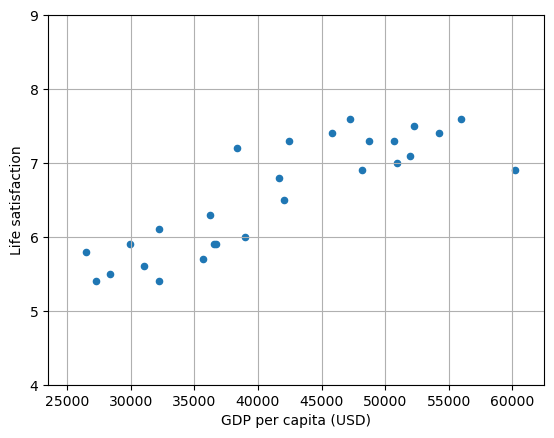

In [2]:
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y= "Life satisfaction")
plt.axis([23_500,62_500,4,9])
plt.show()

In [4]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [5]:
X_new = [[37_655.2]]
print(model.predict(X_new))

[[6.30165767]]


In [7]:
model = Ridge()
model.fit(X, y)
print(model.predict(X_new))

[[6.30165767]]


In [8]:
model = RidgeCV()
model.fit(X, y)
print(model.predict(X_new))

[[6.30165768]]


In [15]:
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X, y)
print(model.predict(X_new))

[[6.37]]


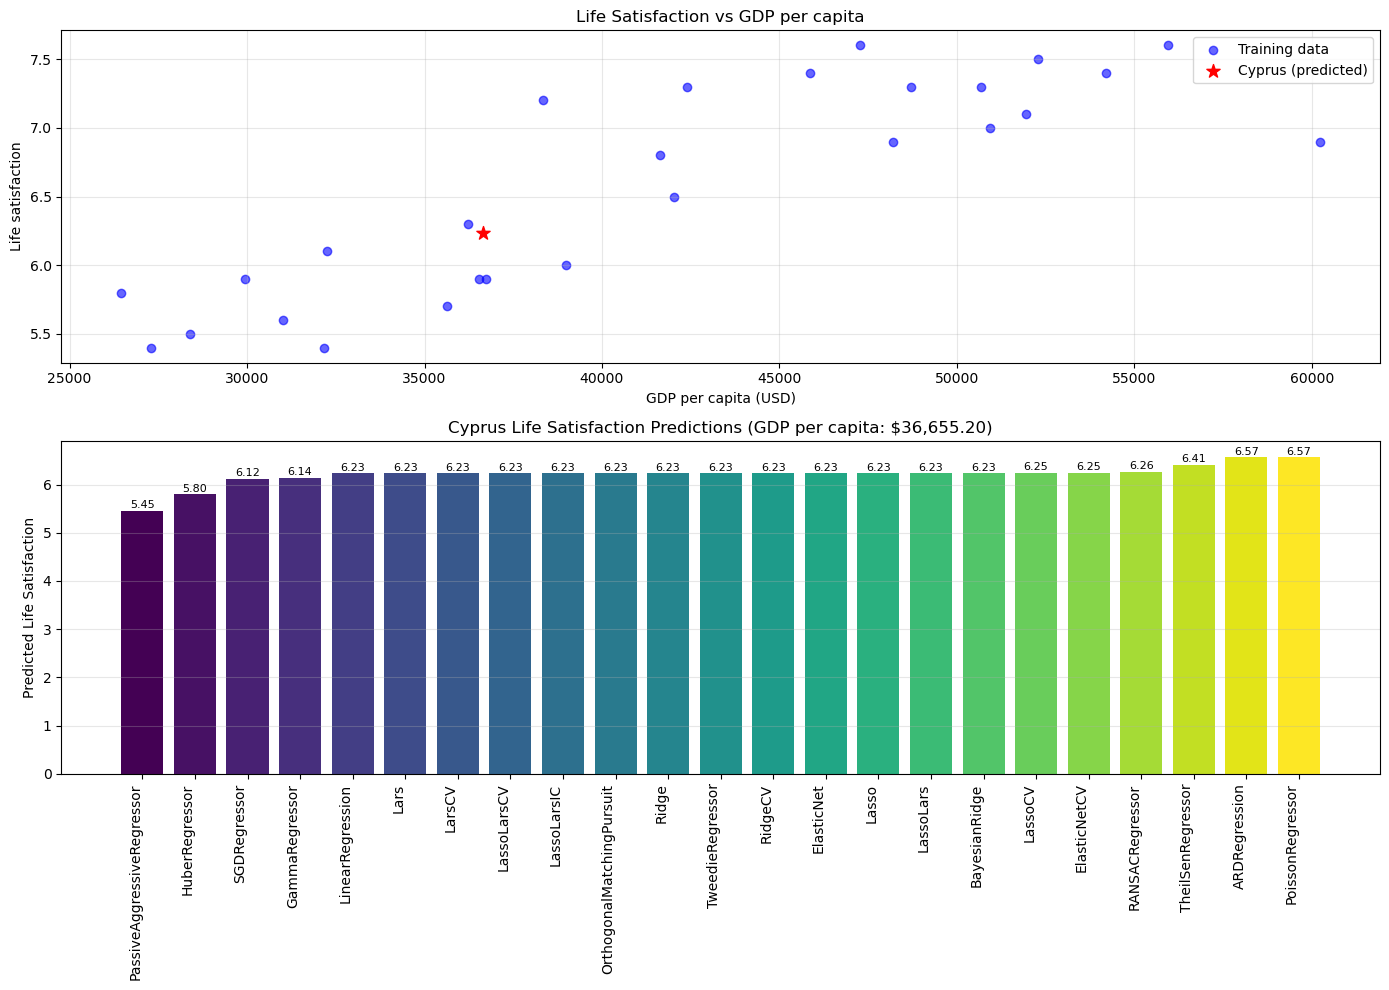


Summary Statistics:
Mean prediction: 6.211
Median prediction: 6.234
Standard deviation: 0.214
Min prediction: 5.455
Max prediction: 6.567

All predictions for Cyprus:
                     Model Prediction
PassiveAggressiveRegressor      5.455
            HuberRegressor      5.802
              SGDRegressor      6.118
            GammaRegressor      6.141
          LinearRegression      6.234
                      Lars      6.234
                    LarsCV      6.234
               LassoLarsCV      6.234
               LassoLarsIC      6.234
 OrthogonalMatchingPursuit      6.234
                     Ridge      6.234
          TweedieRegressor      6.234
                   RidgeCV      6.234
                ElasticNet      6.234
                     Lasso      6.234
                 LassoLars      6.234
             BayesianRidge      6.234
                   LassoCV      6.248
              ElasticNetCV      6.248
           RANSACRegressor      6.263
         TheilSenRegressor      6.

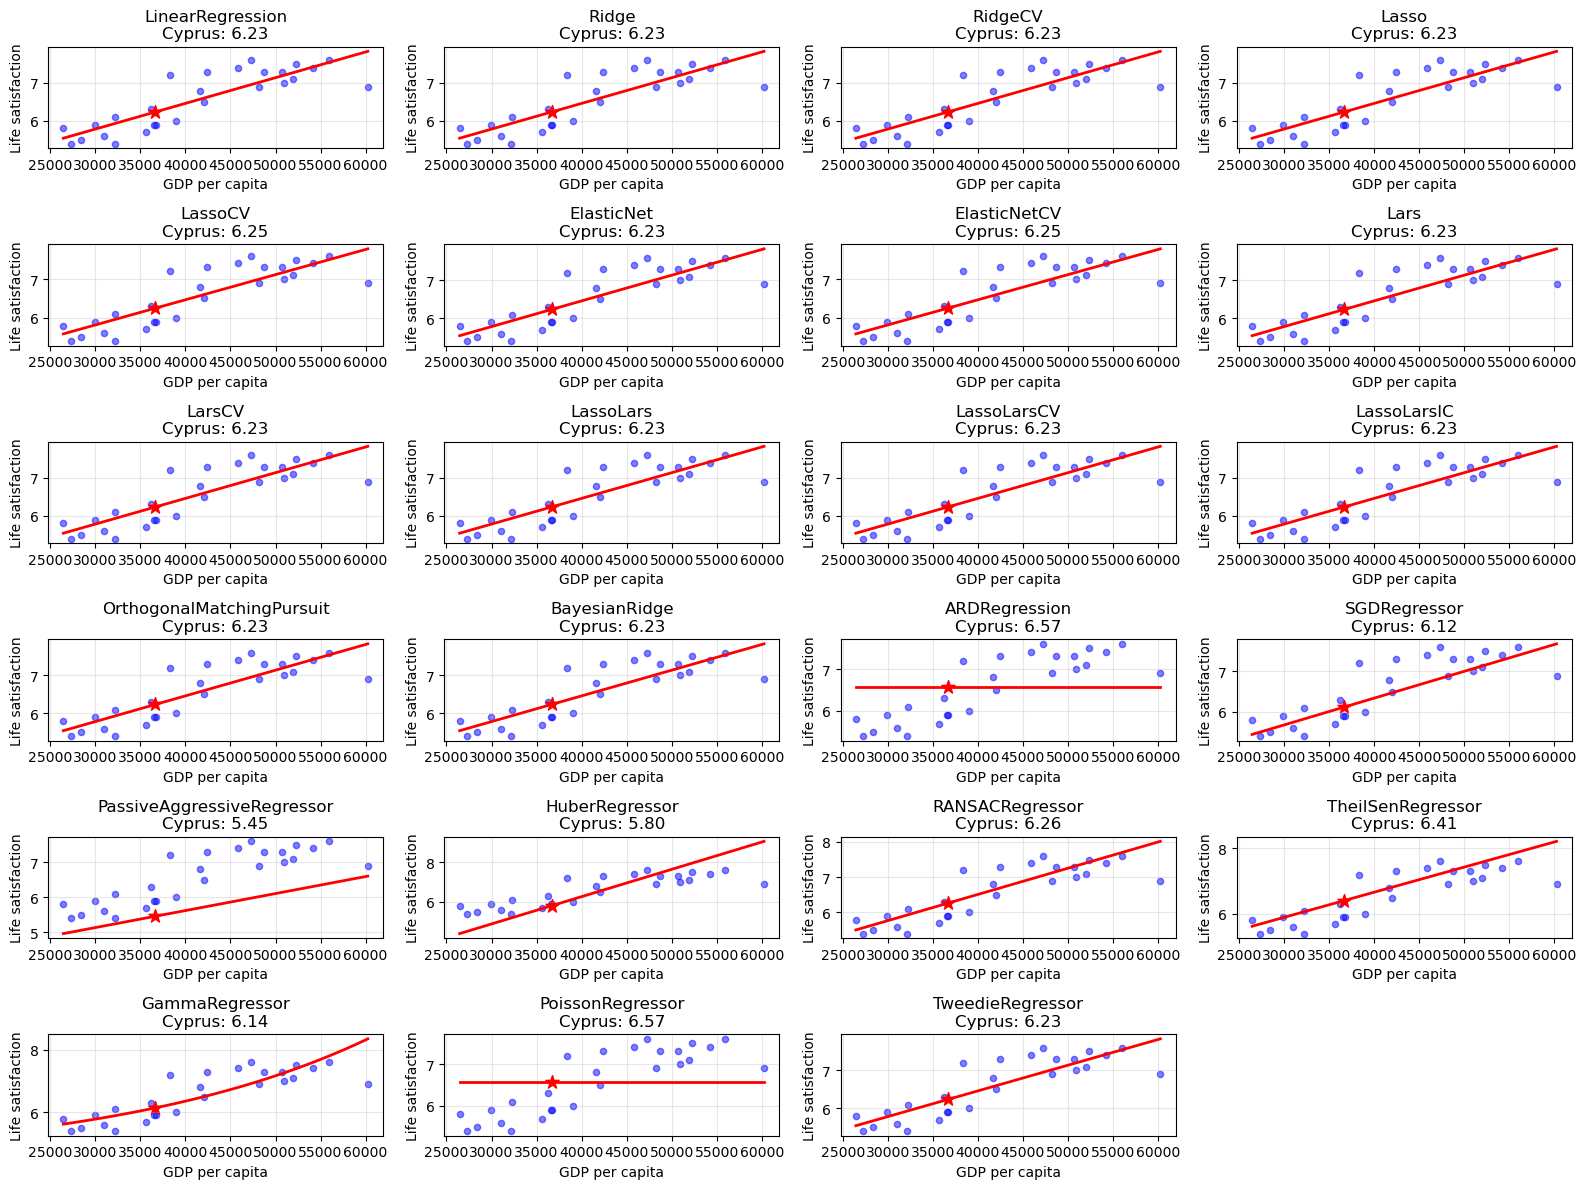

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, 
    ElasticNet, ElasticNetCV, Lars, LarsCV, LassoLars, 
    LassoLarsCV, LassoLarsIC, OrthogonalMatchingPursuit, 
    OrthogonalMatchingPursuitCV, BayesianRidge, ARDRegression, 
    SGDRegressor, PassiveAggressiveRegressor, HuberRegressor, 
    RANSACRegressor, TheilSenRegressor, GammaRegressor, 
    PoissonRegressor, TweedieRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Download the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Cyprus GDP
cyprus_X = np.array([[36_655.2]])

# List of regression models to test
regression_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RidgeCV': RidgeCV(alphas=[0.1, 1.0, 10.0]),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'LassoCV': LassoCV(cv=5, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'ElasticNetCV': ElasticNetCV(cv=5, max_iter=10000),
    'Lars': Lars(),
    'LarsCV': LarsCV(cv=5),
    'LassoLars': LassoLars(alpha=0.1),
    'LassoLarsCV': LassoLarsCV(cv=5),
    'LassoLarsIC': LassoLarsIC(criterion='aic'),
    'OrthogonalMatchingPursuit': OrthogonalMatchingPursuit(),
    'BayesianRidge': BayesianRidge(),
    'ARDRegression': ARDRegression(),
    'SGDRegressor': SGDRegressor(max_iter=10000, tol=1e-3),
    'PassiveAggressiveRegressor': PassiveAggressiveRegressor(max_iter=10000),
    'HuberRegressor': HuberRegressor(max_iter=1000),
    'RANSACRegressor': RANSACRegressor(),
    'TheilSenRegressor': TheilSenRegressor(),
    'GammaRegressor': GammaRegressor(),
    'PoissonRegressor': PoissonRegressor(max_iter=1000),
    'TweedieRegressor': TweedieRegressor(power=0, max_iter=1000),
}

# Some models need scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cyprus_X_scaled = scaler.transform(cyprus_X)

# Some models need positive targets
y_positive = y - y.min() + 1  # Shift to make all values positive

# Dictionary to store predictions
predictions = {}

# Fit each model and make predictions
for name, model in regression_models.items():
    try:
        # Some models require specific data preprocessing
        if name in ['GammaRegressor', 'PoissonRegressor']:
            # These models need positive targets
            model.fit(X, y_positive)
            pred = model.predict(cyprus_X)
            # Shift prediction back
            pred = pred + y.min() - 1
        elif name in ['SGDRegressor', 'PassiveAggressiveRegressor']:
            # These models work better with scaled data
            model.fit(X_scaled, y.ravel())
            pred = model.predict(cyprus_X_scaled)
        else:
            model.fit(X, y)
            pred = model.predict(cyprus_X)
        
        # Ensure we have a scalar value
        if isinstance(pred, np.ndarray):
            if pred.ndim > 1:
                pred = pred.ravel()
            predictions[name] = float(pred[0])
        elif hasattr(pred, '__len__'):
            predictions[name] = float(pred[0])
        else:
            predictions[name] = float(pred)
        
    except Exception as e:
        print(f"Error with {name}: {str(e)}")
        predictions[name] = np.nan

# Clean up predictions to ensure they're all float values
predictions = {k: float(v) if not np.isnan(v) else np.nan for k, v in predictions.items()}

# Sort predictions for better visualization
sorted_predictions = dict(sorted(predictions.items(), 
                                key=lambda x: x[1] if not np.isnan(x[1]) else float('inf')))

# Create the plot
plt.figure(figsize=(14, 10))

# Plot the data points
plt.subplot(2, 1, 1)
plt.scatter(X, y, color='blue', alpha=0.6, label='Training data')
plt.scatter(cyprus_X, list(predictions.values())[0], color='red', s=100, marker='*', label='Cyprus (predicted)')
plt.xlabel('GDP per capita (USD)')
plt.ylabel('Life satisfaction')
plt.title('Life Satisfaction vs GDP per capita')
plt.legend()
plt.grid(True, alpha=0.3)

# Create bar plot of predictions
plt.subplot(2, 1, 2)
models = list(sorted_predictions.keys())
values = list(sorted_predictions.values())

# Convert values to proper float array to avoid the error
values_array = np.array([float(v) if not np.isnan(v) else 0.0 for v in values])

# Create color map
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

bars = plt.bar(range(len(models)), values_array, color=colors)
plt.xticks(range(len(models)), models, rotation=90, ha='right')
plt.ylabel('Predicted Life Satisfaction')
plt.title(f'Cyprus Life Satisfaction Predictions (GDP per capita: ${cyprus_X[0][0]:,.2f})')
plt.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    if not np.isnan(value):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Model': list(sorted_predictions.keys()),
    'Prediction': [f'{v:.3f}' if not np.isnan(v) else 'Failed' for v in sorted_predictions.values()]
})

# Print summary statistics
valid_predictions = [v for v in predictions.values() if not np.isnan(v)]
print("\nSummary Statistics:")
print(f"Mean prediction: {np.mean(valid_predictions):.3f}")
print(f"Median prediction: {np.median(valid_predictions):.3f}")
print(f"Standard deviation: {np.std(valid_predictions):.3f}")
print(f"Min prediction: {np.min(valid_predictions):.3f}")
print(f"Max prediction: {np.max(valid_predictions):.3f}")

# Show the predictions table
print("\nAll predictions for Cyprus:")
print(summary_df.to_string(index=False))

# Additional visualization: Plot each model's fit
plt.figure(figsize=(16, 12))

# Create a grid of subplots
n_models = len(regression_models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_scaled = scaler.transform(X_plot)

for idx, (name, model) in enumerate(regression_models.items(), 1):
    plt.subplot(n_rows, n_cols, idx)
    
    try:
        # Plot the original data
        plt.scatter(X, y, alpha=0.5, color='blue', s=20)
        
        # Generate predictions for the plot range
        if name in ['GammaRegressor', 'PoissonRegressor']:
            y_plot = model.predict(X_plot) + y.min() - 1
        elif name in ['SGDRegressor', 'PassiveAggressiveRegressor']:
            y_plot = model.predict(X_plot_scaled)
        else:
            y_plot = model.predict(X_plot)
        
        # Plot the model's prediction line
        plt.plot(X_plot, y_plot, 'r-', linewidth=2)
        
        # Mark Cyprus prediction
        if not np.isnan(predictions[name]):
            plt.scatter(cyprus_X, predictions[name], color='red', s=100, marker='*')
        
        plt.title(f'{name}\nCyprus: {predictions[name]:.2f}' if not np.isnan(predictions[name]) else f'{name}\nFailed')
        plt.xlabel('GDP per capita')
        plt.ylabel('Life satisfaction')
        
    except Exception as e:
        plt.text(0.5, 0.5, f'Error: {str(e)[:30]}...', 
                ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()